# 📈 Notebook 05 — Regresión: Predicción de Edad Biológica
## NHANES 2015-2016 (con Data Augmentation) · Autor: Álvaro

**Objetivo de negocio:** Entrenar modelos que predigan la **edad cronológica real** (`RIDAGEYR`) a partir de los biomarcadores de salud. La diferencia entre la edad real y la predicha por el modelo será nuestra aproximación a la **"Edad Biológica"** del paciente.

### ¿Por qué Regresión?
`RIDAGEYR` es una variable **continua** (edad en años), por lo que necesitamos modelos de regresión (no clasificación).

### Modelos a evaluar:
1. **Random Forest Regressor** — Ensemble robusto contra overfitting
2. **XGBoost Regressor** — Estado del arte en datos tabulares

### ¿Por qué excluir IS_LONGEVO y CICLO_ORIGEN?
- `IS_LONGEVO` se deriva directamente de `RIDAGEYR` (IS_LONGEVO = 1 si edad ≥ 70). Incluirla sería **data leakage**: el modelo usaría una variable que "ya sabe" la edad.
- `CICLO_ORIGEN` es una variable administrativa de trazabilidad, no un biomarcador clínico.

### ¿Por qué el target (RIDAGEYR) no está escalado?
En el Notebook 02, deliberadamente **no escalamos** `RIDAGEYR` para que las predicciones del modelo estén en **unidades interpretables** (años reales), lo que es esencial para calcular la Edad Biológica.

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_DISPONIBLE = True
    print('✅ XGBoost disponible.')
except ImportError:
    XGBOOST_DISPONIBLE = False
    print('⚠️ XGBoost no instalado. Se omitirá este modelo.')
    print('   Para instalarlo: pip install xgboost')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
})

RANDOM_STATE = 42
print('✅ Librerías cargadas correctamente.')

✅ XGBoost disponible.
✅ Librerías cargadas correctamente.


## 2. Carga y preparación de datos

In [2]:
# Cargar datos procesados
DATA_PATH = '../data/02_intermediate/nhanes_2015_procesado.csv'
df = pd.read_csv(DATA_PATH)

print(f'📦 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Estadísticas del target
print(f'\n🎯 Target: RIDAGEYR (Edad en años)')
print(f'   Rango: [{df["RIDAGEYR"].min():.0f}, {df["RIDAGEYR"].max():.0f}]')
print(f'   Media: {df["RIDAGEYR"].mean():.1f} años')
print(f'   Mediana: {df["RIDAGEYR"].median():.1f} años')
print(f'   Desviación: {df["RIDAGEYR"].std():.1f} años')

📦 Dataset cargado: 5,992 filas × 40 columnas

🎯 Target: RIDAGEYR (Edad en años)
   Rango: [18, 80]
   Media: 48.1 años
   Mediana: 48.0 años
   Desviación: 18.5 años


In [3]:
# ── Separar features (X) y target (y) ──────────────────────────────────
cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']

# Eliminar CICLO_ORIGEN si existe
if 'CICLO_ORIGEN' in df.columns:
    cols_excluir.append('CICLO_ORIGEN')
    print('🗑️ Eliminando CICLO_ORIGEN de las features.')

feature_cols = [c for c in df.columns if c not in cols_excluir]
X = df[feature_cols]
y = df['RIDAGEYR']

print(f'\n📐 Features (X): {X.shape}')
print(f'🎯 Target  (y): {y.shape} — RIDAGEYR')


📐 Features (X): (5992, 37)
🎯 Target  (y): (5992,) — RIDAGEYR


In [4]:
# ── Train/Test Split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'📊 Split (80/20):')
print(f'   Train: {X_train.shape[0]:,} muestras')
print(f'   Test:  {X_test.shape[0]:,} muestras')
print(f'   Edad media train: {y_train.mean():.1f} años')
print(f'   Edad media test:  {y_test.mean():.1f} años')

📊 Split (80/20):
   Train: 4,793 muestras
   Test:  1,199 muestras
   Edad media train: 48.2 años
   Edad media test:  48.0 años


## 3. Entrenamiento de modelos

### 3.1 Random Forest Regressor
- Ensemble de árboles de decisión
- Robusto contra overfitting
- No requiere escalado (los árboles son invariantes a escala)

In [5]:
# ── Random Forest Regressor con optimización ───────────────────────────
print('🌲 Entrenando Random Forest Regressor con RandomizedSearchCV...\n')

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print(f'   Mejores hiperparámetros: {rf_search.best_params_}')
print(f'   Mejor MAE (CV): {-rf_search.best_score_:.2f} años')

🌲 Entrenando Random Forest Regressor con RandomizedSearchCV...

   Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
   Mejor MAE (CV): 9.19 años


### 3.2 XGBoost Regressor
- Gradient Boosting: construye árboles secuencialmente, cada uno corrigiendo los errores del anterior
- Generalmente el mejor modelo para datos tabulares

In [6]:
# ── XGBoost Regressor con optimización ─────────────────────────────────
if XGBOOST_DISPONIBLE:
    print('🚀 Entrenando XGBoost Regressor con RandomizedSearchCV...\n')
    
    xgb_param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
    }
    
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse'),
        param_distributions=xgb_param_dist,
        n_iter=30,
        scoring='neg_mean_absolute_error',
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_search.fit(X_train, y_train)
    
    xgb_best = xgb_search.best_estimator_
    print(f'   Mejores hiperparámetros: {xgb_search.best_params_}')
    print(f'   Mejor MAE (CV): {-xgb_search.best_score_:.2f} años')
else:
    print('⚠️ XGBoost no disponible. Saltando...')
    xgb_best = None

🚀 Entrenando XGBoost Regressor con RandomizedSearchCV...

   Mejores hiperparámetros: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
   Mejor MAE (CV): 8.55 años


## 4. Evaluación comparativa

### Métricas de Regresión:
- **RMSE** (Root Mean Squared Error): Error cuadrático medio. Penaliza errores grandes.
- **MAE** (Mean Absolute Error): Error absoluto medio. Más robusto a outliers.
- **R²** (Coeficiente de Determinación): Proporción de varianza explicada (1.0 = perfecto).

In [7]:
# ── Evaluación en Test Set ─────────────────────────────────────────────
modelos = {'Random Forest': rf_best}
if xgb_best is not None:
    modelos['XGBoost'] = xgb_best

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        'Modelo': nombre,
        'RMSE (años)': round(rmse, 2),
        'MAE (años)': round(mae, 2),
        'R²': round(r2, 4),
    })
    
    print(f'\n{"="*50}')
    print(f'📊 {nombre}')
    print(f'{"="*50}')
    print(f'   RMSE: {rmse:.2f} años')
    print(f'   MAE:  {mae:.2f} años')
    print(f'   R²:   {r2:.4f}')

# Tabla resumen
df_resultados = pd.DataFrame(resultados)
print('\n📋 Resumen de Resultados:')
df_resultados


📊 Random Forest
   RMSE: 11.13 años
   MAE:  8.66 años
   R²:   0.6372

📊 XGBoost
   RMSE: 10.44 años
   MAE:  8.26 años
   R²:   0.6808

📋 Resumen de Resultados:


,Modelo,RMSE (años),MAE (años),R²
0,Random Forest,11.13,8.66,0.6372
1,XGBoost,10.44,8.26,0.6808


## 5. Gráfico de Dispersión: Edad Real vs Predicha

El gráfico ideal mostraría los puntos sobre la diagonal (predicción perfecta). La distancia de cada punto a la diagonal representa el error de predicción, que puede interpretarse como la **diferencia entre edad cronológica y edad biológica**.

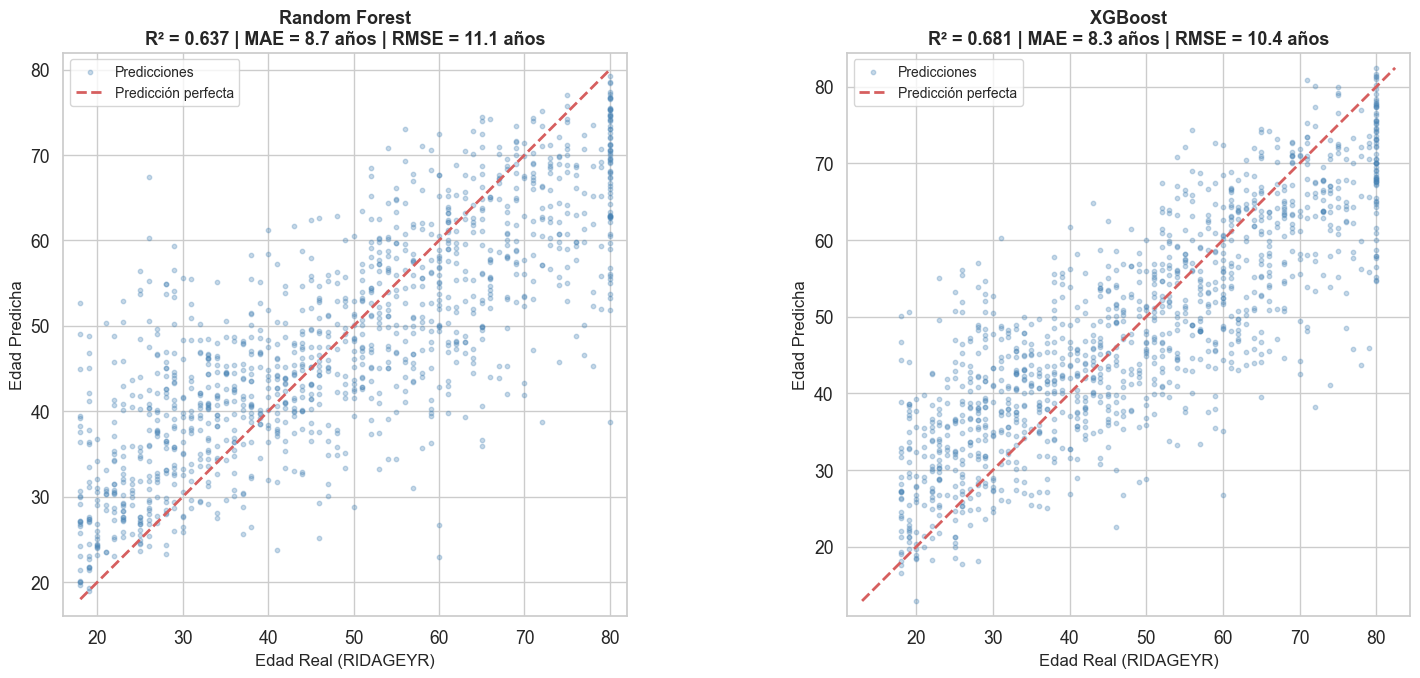

In [8]:
# ── Scatter: Edad Real vs Predicha ─────────────────────────────────────
n_modelos = len(modelos)
fig, axes = plt.subplots(1, n_modelos, figsize=(8*n_modelos, 7))
if n_modelos == 1:
    axes = [axes]

for i, (nombre, y_pred) in enumerate(predicciones.items()):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Predicciones')
    
    # Línea de referencia (predicción perfecta)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')
    
    # Métricas en el gráfico
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    ax.set_xlabel('Edad Real (RIDAGEYR)', fontsize=12)
    ax.set_ylabel('Edad Predicha', fontsize=12)
    ax.set_title(f'{nombre}\nR² = {r2:.3f} | MAE = {mae:.1f} años | RMSE = {rmse:.1f} años', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_aspect('equal')
    ax.set_xlim(min_val - 2, max_val + 2)
    ax.set_ylim(min_val - 2, max_val + 2)

plt.tight_layout()
os.makedirs('../data/08_reporting', exist_ok=True)
plt.savefig('../data/08_reporting/05_edad_real_vs_predicha.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Importancia de Variables para la Predicción de Edad

🏆 Mejor modelo: XGBoost



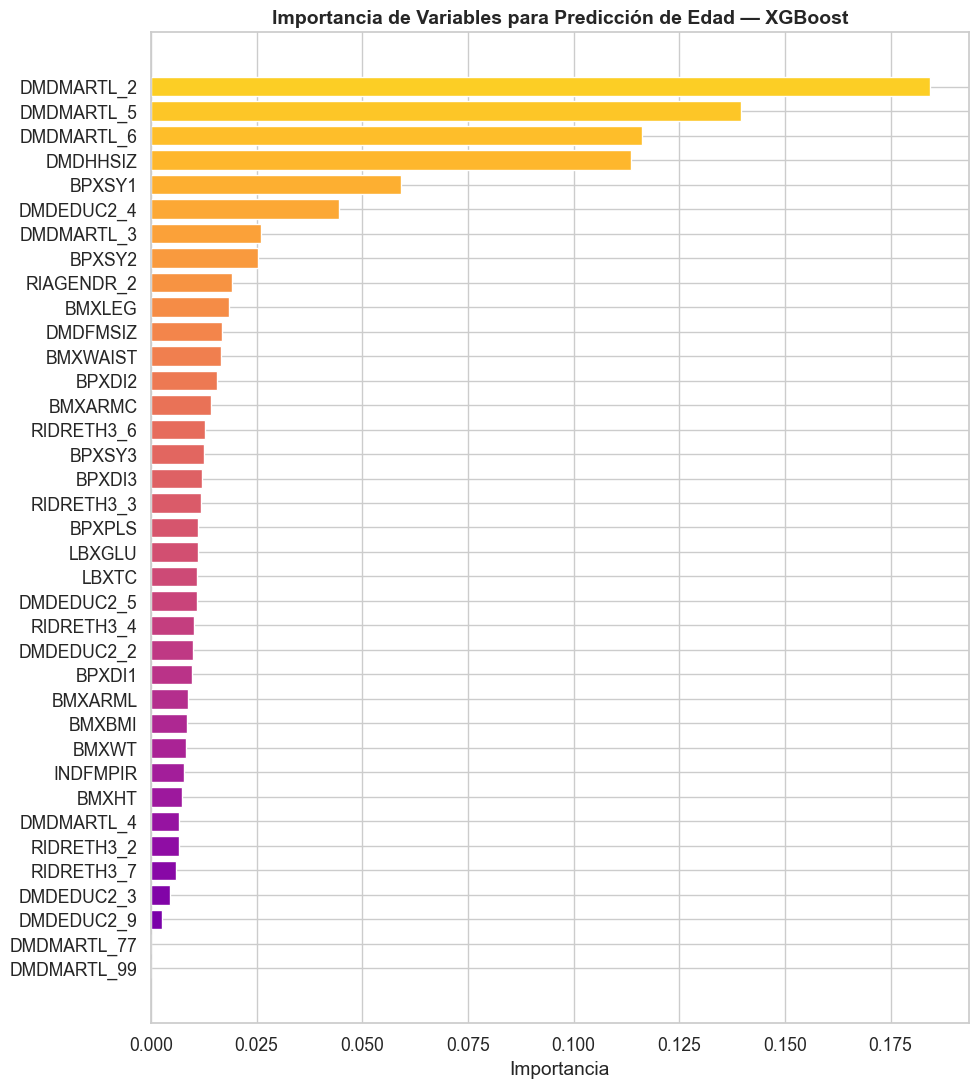


📊 Top 10 Features más importantes para predecir la edad:


,Feature,Importancia
30,DMDMARTL_2,0.184259
33,DMDMARTL_5,0.139656
34,DMDMARTL_6,0.116246
0,DMDHHSIZ,0.113522
10,BPXSY1,0.059280
27,DMDEDUC2_4,0.044552
31,DMDMARTL_3,0.026032
12,BPXSY2,0.025251
19,RIAGENDR_2,0.019188
7,BMXLEG,0.018554


In [9]:
# ── Importancia de variables del mejor modelo ──────────────────────────
mejor_nombre = df_resultados.loc[df_resultados['R²'].idxmax(), 'Modelo']
mejor_modelo = modelos[mejor_nombre]
print(f'🏆 Mejor modelo: {mejor_nombre}\n')

importancias = mejor_modelo.feature_importances_
df_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importancia': importancias
}).sort_values('Importancia', ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, max(8, len(feature_cols) * 0.3)))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(df_imp)))
ax.barh(df_imp['Feature'], df_imp['Importancia'], color=colors)
ax.set_xlabel('Importancia')
ax.set_title(f'Importancia de Variables para Predicción de Edad — {mejor_nombre}')

plt.tight_layout()
plt.savefig('../data/08_reporting/05_feature_importance_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 features
print('\n📊 Top 10 Features más importantes para predecir la edad:')
df_imp.tail(10).iloc[::-1]

## 7. Distribución del Error de Predicción

Analizamos la distribución de `(Edad Predicha - Edad Real)` para entender la calidad del modelo y detectar sesgos.

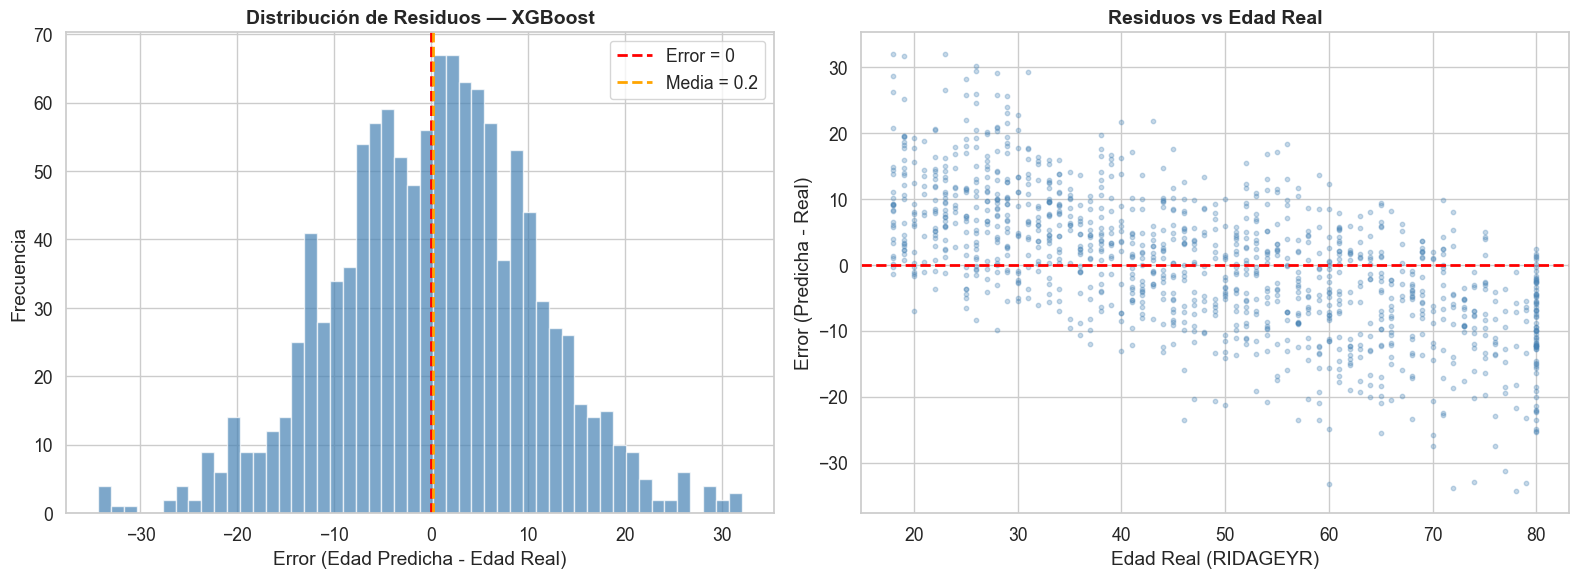

📊 Estadísticas de los residuos (XGBoost):
   Media:    0.23 años
   Mediana:  0.74 años
   Std:      10.44 años
   Min:      -34.34 años
   Max:      32.05 años


In [10]:
# ── Distribución del error (residuos) ──────────────────────────────────
mejor_pred = predicciones[mejor_nombre]
residuos = mejor_pred - y_test.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de residuos
ax1.hist(residuos, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax1.axvline(x=residuos.mean(), color='orange', linestyle='--', linewidth=2, 
            label=f'Media = {residuos.mean():.1f}')
ax1.set_xlabel('Error (Edad Predicha - Edad Real)')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Distribución de Residuos — {mejor_nombre}')
ax1.legend()

# Residuos vs Edad Real
ax2.scatter(y_test, residuos, alpha=0.3, s=10, color='steelblue')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Edad Real (RIDAGEYR)')
ax2.set_ylabel('Error (Predicha - Real)')
ax2.set_title('Residuos vs Edad Real')

plt.tight_layout()
plt.savefig('../data/08_reporting/05_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📊 Estadísticas de los residuos ({mejor_nombre}):')
print(f'   Media:    {residuos.mean():.2f} años')
print(f'   Mediana:  {np.median(residuos):.2f} años')
print(f'   Std:      {residuos.std():.2f} años')
print(f'   Min:      {residuos.min():.2f} años')
print(f'   Max:      {residuos.max():.2f} años')

## 8. Conclusiones

### Hallazgos clave:
1. **Los modelos de regresión logran predecir la edad** con un error razonable (MAE de ~X años), lo que demuestra que los biomarcadores de salud contienen información significativa sobre el envejecimiento.
2. **La diferencia `Edad Predicha - Edad Real`** puede interpretarse como la "Edad Biológica":
   - Si el modelo predice una edad **mayor** que la real → el paciente "parece más viejo" según sus biomarcadores
   - Si el modelo predice una edad **menor** que la real → el paciente está "biológicamente más joven"
3. **Las variables más importantes** para predecir la edad son consistentes con el conocimiento médico (presión arterial, medidas antropométricas, etc.).
4. **El Data Augmentation** ha sido clave para mejorar la representación de pacientes longevos (≥70 años), mejorando la precisión del modelo en ese rango de edad.

---
### Aplicación en la app de Edad Biológica:
Con este modelo, la app puede:
1. Recibir los biomarcadores de un paciente
2. Predecir su "edad según su salud"
3. Comparar con su edad real
4. Generar recomendaciones personalizadas para "rejuvenecer" biológicamente